In [2]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, vmap, jit
import matplotlib.pyplot as plt
import pymaster as nmt
from tqdm import tqdm
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy import units as u
from pathlib import Path
# import cpcl_cov
jax.config.update("jax_enable_x64", True)


from brute_cov import (
    build_binning_matrix, pad_binning_matrix,
    compute_cos_theta, mcm_binning,
    compute_legendre,
    sample_covariance_healpy,
)
from utils2 import *

In [3]:
import numpy as np
import healpy as hp

def assign_weights_from_mask(ra, dec, mask_map, nside=None):
    """Look up the mask value at each (ra, dec) position and use it as a weight.

    ra, dec : arrays in degrees (dec in [-90, 90], ra in [0, 360) or [-180, 180))
    mask_map: HEALPix map (RING ordering, as produced by generate_chime_mask.py)
    nside   : HEALPix NSIDE of mask_map; inferred from len(mask_map) if not given
    """
    ra  = np.asarray(ra, dtype=float)
    dec = np.asarray(dec, dtype=float)

    if nside is None:
        nside = hp.npix2nside(len(mask_map))

    theta = np.radians(90.0 - dec)          # colatitude
    phi   = np.radians(np.where(ra < 0, ra + 360.0, ra))  # wrap to [0, 360)

    ipix = hp.ang2pix(nside, theta, phi)    # nearest-pixel lookup
    weights = mask_map[ipix]
    return weights

In [4]:
compute_legendre_jitted = jax.jit(compute_legendre, static_argnames='lmax')
@jax.jit
def corr(s, P):
    return jnp.einsum('l, lij->ij', s, P)


In [5]:
#data = np.load("mock_masked_fixed.npz")
data = np.load("/home/s59efara_hpc/covariance/pseudo_catcell_covariance_benchmark/output/mock_mod_patch_fixed.npz")

print(data.files)

['ra', 'dec', 'ell', 'cell', 'nside_sim', 'noise_mean', 'noise_var', 'position_source', 'position_mask_mode', 'DM', 'DM_gaussian', 'DM_lognormal', 'n_completed', 'pcl_ell_eff', 'pcl_edges', 'pcl_dm', 'pcl_dm_gaussian', 'pcl_dm_lognormal', 'pcl_theory']


In [6]:
RA = data['ra']
DEC = data['dec']
DM = data['DM']
# DM_gaussian = data['series']['DM_gaussian']
# DM_lognormal = data['series']['DM_lognormal']

transformation = SkyCoord(ra=RA*u.degree, dec=DEC*u.degree, frame='icrs').galactic
gl, gb = np.array(transformation.l), np.array(transformation.b)
pos = np.array([gl, gb])

In [7]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt


def plot_sources_healpix(ra, dec, nside=128, title="Source positions",
                          overlay_scatter=False, log_scale=False,
                          cmap="viridis", save_path=None):
    """Plot RA/Dec source positions on a HEALPix map.

    Parameters
    ----------
    ra, dec : array-like, degrees
    nside   : HEALPix resolution for the density map
    overlay_scatter : if True, also scatter individual points on top
                       (only recommended for modest N_sources, e.g. < ~5000,
                       since projplot gets slow/cluttered for large catalogs)
    log_scale : if True, use log10(1+counts) instead of raw counts
                (helpful when a few pixels dominate, e.g. near a sharp
                mask edge or an oversampled patch)
    """
    ra  = np.asarray(ra, dtype=float)
    dec = np.asarray(dec, dtype=float)
    ra_wrapped = np.where(ra < 0, ra + 360.0, ra)

    npix = hp.nside2npix(nside)
    theta = np.radians(90.0 - dec)
    phi   = np.radians(ra_wrapped)
    ipix  = hp.ang2pix(nside, theta, phi)

    counts = np.bincount(ipix, minlength=npix).astype(float)
    density_map = np.log10(1.0 + counts) if log_scale else counts

    # Mask empty pixels so they render as background rather than "zero density"
    display_map = np.where(counts > 0, density_map, np.nan)

    fig = plt.figure(figsize=(11, 5.5))
    hp.mollview(
        display_map,
        fig=fig.number,
        title=title,
        unit=("log10(1+N) per pixel" if log_scale else "N sources per pixel"),
        cmap=cmap,
        hold=True,
    )
    hp.graticule(dpar=30, dmer=60, alpha=0.4)

    if overlay_scatter:
        hp.projscatter(theta, phi, s=2, color="red", alpha=0.4)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Plot saved: {save_path}")
    plt.show()

    print(f"  N sources        : {len(ra)}")
    print(f"  Non-empty pixels : {int((counts > 0).sum())} / {npix}  "
          f"(f_sky_occupied = {(counts > 0).sum() / npix:.4f})")
    print(f"  Max sources/pixel: {int(counts.max())}")


# --- Example usage ---
# data = np.load("mock_mod_patch_63c1dd95_fixed.npz")
# plot_sources_healpix(data["ra"], data["dec"], nside=128,
#               title="Sampled catalogue positions",
#                       log_scale=True)

/tmp/ipykernel_41557/3859359492.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


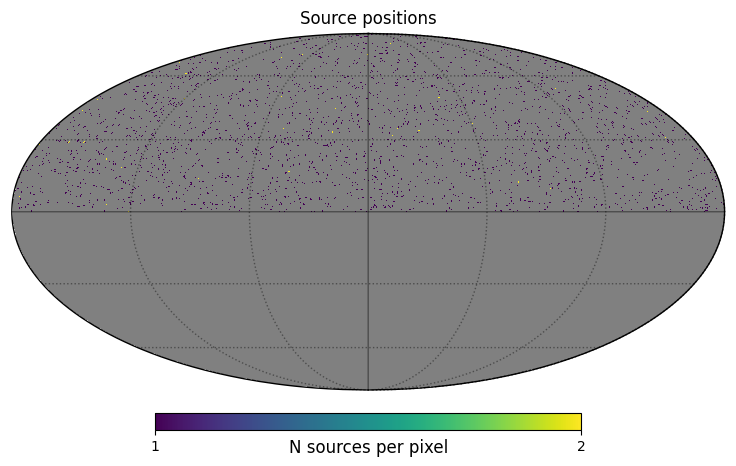

  N sources        : 3000
  Non-empty pixels : 2961 / 196608  (f_sky_occupied = 0.0151)
  Max sources/pixel: 2


In [8]:
plot_sources_healpix(RA, DEC)

In [9]:
edges = data['pcl_edges']
lmin = np.min(edges)
lmax_nside = np.max(edges)
lmax = lmax_nside
b = nmt.NmtBin.from_edges(edges[:-1], edges[1:])
w = jnp.ones(RA.size)

#mask_path = "/home/s59efara_hpc/covariance/pseudo_catcell_covariance_benchmark/output/chime/chime_mask_cosine_nside1024.fits"
#mask = hp.read_map(mask_path)
#w = jnp.array(assign_weights_from_mask(RA, DEC, mask, nside=1024))

In [49]:
f_mask = nmt.NmtFieldCatalog(positions = [gl, gb], weights = w, field= None,
                         lmax = b.lmax, spin = 0, lonlat=True )    


wasp = nmt.NmtWorkspace.from_fields(f_mask, f_mask, b)
mcm = np.asarray(wasp.get_coupling_matrix(), dtype=np.float64)


Binning, ell_eff = build_binning_matrix(edges)
Binning_matrix_padded = pad_binning_matrix(Binning, lmin, lmax)
mcm_binnedB = (Binning_matrix_padded @ mcm_np @ Binning_matrix_padded.T)
mcm_binned_inv = np.linalg.inv(mcm_binnedB)                                     

#mcm_inv_np = np.linalg.inv(mcm_np)                                    


#mcm_inv = jnp.asarray(mcm_inv_np)

In [55]:
_unbin = np.zeros((lmax, len(edges) - 1))
for _bi in range(len(edges) - 1):
    _unbin[edges[_bi]:edges[_bi + 1], _bi] = 1.0
TB = jnp.array(np.linalg.inv(Binning_matrix_padded @ mcm @ _unbin) @ Binning_matrix_padded)


In [56]:
def sum_matrices(pos, w, TB, lmax, full_ells, Sl_unbinned, noise_variance, chunk_size,
                  field_variance_only=False):
    """
    field_variance_only: if True, replace the signal correlation function xi(theta)
        with a Kronecker delta at zero lag, i.e. xi(theta) -> sigma_field^2 * delta(theta).
        This isolates the "field variance" contribution to the covariance (the term that
        survives when all off-diagonal signal correlations are killed), which combines
        with noise_variance exactly like the usual diagonal term. Useful for validating
        the covariance against e.g. a simple white-noise-plus-field-variance estimate.
    """

    N = pos.shape[1]
    remainder = N % chunk_size
    if remainder != 0:
        pad_size = chunk_size - remainder
        pos = jnp.concatenate([pos, jnp.zeros((pos.shape[0], pad_size))], axis=1)
        w   = jnp.concatenate([w,   jnp.zeros(pad_size)])
    n_chunks = pos.shape[1] // chunk_size
    dim_cov  = TB.shape[0]
    carry_init = jnp.zeros((dim_cov, dim_cov))

    # sigma_field = xi(theta=0) = sum_l (2l+1) Sl / (4 pi), computed exactly
    # rather than via grid interpolation, since it's the coincident-point limit.
    sigma_field = jnp.sum((2 * full_ells + 1) * Sl_unbinned) / (4.0 * np.pi)

    if not field_variance_only:
        N_xi = 100 * lmax
        # Uniform in theta (not cos theta) gives dense sampling near theta=0,
        # resolving the rapidly-oscillating Legendre polynomials at large ell.
        # linspace(pi, 0) -> cos goes from -1 to +1 (ascending, required by jnp.interp).
        cos_theta_grid = jnp.cos(jnp.linspace(jnp.pi, 0.0, N_xi))
        P_1d    = compute_legendre_jitted(cos_theta_grid, lmax)
        xi_grid = jnp.einsum('l, lk -> k',
                             (2 * full_ells + 1) * Sl_unbinned, P_1d) / 4.0 / np.pi
        jax.debug.print('the size is {}', xi_grid.shape)

        def signal_corr_pair(pos_x, pos_y):
            cos_theta = compute_cos_theta(pos_x[0], pos_x[1], pos_y[0], pos_y[1])
            return jnp.interp(cos_theta.ravel(), cos_theta_grid, xi_grid).reshape(cos_theta.shape)

    noise_mat = noise_variance * jnp.eye(chunk_size)
    field_mat = sigma_field * jnp.eye(chunk_size)

    def full_field_corr(pos_p, pos_q, same_chunk):
        """Signal (or delta-only field-variance) correlation plus noise, added
        only on the coincident-chunk diagonal."""
        if field_variance_only:
            # Off-diagonal (different chunk) signal correlation is killed entirely;
            # only the delta-function zero-lag piece + noise survives.
            return lax.cond(same_chunk,
                             lambda: field_mat + noise_mat,
                             lambda: jnp.zeros((chunk_size, chunk_size)))
        else:
            signal_corr_pq = signal_corr_pair(pos_p, pos_q)
            return lax.cond(same_chunk,
                             lambda s, n: s + n,
                             lambda s, n: s,
                             signal_corr_pq, noise_mat)

    def sum_over_i(i, carr_i):
        posi = lax.dynamic_slice(pos, (0, i * chunk_size), (2, chunk_size))
        wi   = lax.dynamic_slice(w,   (i * chunk_size,),  (chunk_size,))

        def sum_over_j(j, carr_j):
            # Exploit f(i,j,a,b) = f(j,i,b,a): only compute j >= i, multiply by 4.
            # For j == i (intra-chunk), use upper triangle to avoid double-counting k<->m.
            def compute_j(_):
                posj = lax.dynamic_slice(pos, (0, j * chunk_size), (2, chunk_size))
                wj   = lax.dynamic_slice(w,   (j * chunk_size,),  (chunk_size,))

                w_ij = wi[:, None] * wj[None, :]
                # For i == j, keep only upper triangle (k < m) since the (j,i,b,a)
                # mirror of the i==j block is itself; lower triangle would double-count.
                w_ij = lax.cond(i == j,
                                lambda x: jnp.triu(x, k=1),
                                lambda x: x, w_ij)

                cos_theta_ij = compute_cos_theta(posi[0], posi[1], posj[0], posj[1])
                P_ij   = compute_legendre_jitted(cos_theta_ij, lmax)
                TBP_ij = mcm_binning(TB, P_ij)

                def sum_over_a(a, carr_a):
                    posa = lax.dynamic_slice(pos, (0, a * chunk_size), (2, chunk_size))
                    wa   = lax.dynamic_slice(w,   (a * chunk_size,),  (chunk_size,))

                    full_field_corr_ia = full_field_corr(posi, posa, i == a)

                    def sum_over_b(b, carr_b):
                        posb = lax.dynamic_slice(pos, (0, b * chunk_size), (2, chunk_size))
                        wb   = lax.dynamic_slice(w,   (b * chunk_size,),  (chunk_size,))

                        w_ab = wa[:, None] * wb[None, :]
                        w_ab = lax.cond(a == b,
                                        lambda x: x - jnp.diag(jnp.diag(x)),
                                        lambda x: x, w_ab)

                        cos_theta_ab   = compute_cos_theta(posa[0], posa[1], posb[0], posb[1])
                        P_ab           = compute_legendre_jitted(cos_theta_ab, lmax)
                        TBP_ab         = mcm_binning(TB, P_ab)

                        full_field_corr_jb = full_field_corr(posj, posb, j == b)

                        Cov_binned = (4 * jnp.einsum('ij, aij, km, bkm, ik, jm -> ab',
                                                      w_ij, TBP_ij,
                                                      w_ab, TBP_ab,
                                                      full_field_corr_ia,
                                                      full_field_corr_jb) / (4 * np.pi) ** 2)
                        jax.debug.print('The value of the indices is {} {} {} {}', i, j, a, b)

                        return carr_b + Cov_binned

                    return lax.fori_loop(0, n_chunks, sum_over_b, carr_a)

                return lax.fori_loop(0, n_chunks, sum_over_a, carr_j)

            return lax.cond(j >= i, compute_j, lambda _: carr_j, None)

        return lax.fori_loop(0, n_chunks, sum_over_j, carr_i)

    return lax.fori_loop(0, n_chunks, sum_over_i, carry_init)


sum_matrices_jitted = jit(sum_matrices, static_argnames=('lmax', 'chunk_size', 'field_variance_only'))

In [57]:
n_chunks = RA.size


#f = nmt.NmtFieldCatalog(positions = [gl, gb], weights=w, field = DM[None, :], lmax=b.lmax, lonlat=True, spin = 0)

#Sl_coupled = nmt.compute_coupled_cell(f, f) # the coupled, noise subtracted power spectrum  
#Nf = f.Nf
#Sl = wasp.decouple_cell(Sl_coupled)
#Sl_unbinned = b.unbin_cell(Sl)[0]

ells = b.get_effective_ells()



full_ells = jnp.arange(0, edges[-1])



cl_th = data['cell']
cl_th_coupled = wasp.couple_cell(cl_th[None, :edges[-1]])
cl_th_decoupled = wasp.decouple_cell(cl_th_coupled)
cl_th_decoupled_unbinned = b.unbin_cell(cl_th_decoupled)[0]

cov = np.cov(data['pcl_dm'].T)



field_variance = jnp.sum((2*full_ells + 1)*cl_th[:edges[-1]])/4./np.pi
var_f = np.var(DM) + np.mean(DM)**2
noise_variance = var_f - field_variance

In [58]:
# Block jackknife error on the sample covariance from the data realisations.
# With N=10000 and n_blocks=100 each block holds 100 realisations;
# each leave-one-out estimate uses 9900 realisations.
n_blocks = 100
pcl_dm   = data['pcl_dm']          # shape (N_real, nbins)
N_real   = pcl_dm.shape[0]
block_size = N_real // n_blocks

cov_jk = np.zeros((n_blocks, cov.shape[0], cov.shape[1]))
for k in range(n_blocks):
    mask = np.ones(N_real, dtype=bool)
    mask[k * block_size : (k + 1) * block_size] = False
    cov_jk[k] = np.cov(pcl_dm[mask].T)

cov_jk_mean = cov_jk.mean(axis=0)
cov_err = np.sqrt((n_blocks - 1) / n_blocks * np.sum((cov_jk - cov_jk_mean) ** 2, axis=0))

# Error on sigma = sqrt(cov_diag) via error propagation
sigma_data     = np.sqrt(np.diag(cov))
sigma_data_err = np.diag(cov_err) / (2 * sigma_data)

print('Diagonal fractional jackknife error (cov_err / cov):',
      np.diag(cov_err) / np.diag(cov))

Diagonal fractional jackknife error (cov_err / cov): [0.05923323 0.05935138 0.0509876  0.05122242 0.04208684 0.04329352
 0.04983705 0.04456864 0.04866646 0.0407976  0.04574342 0.04775908]


In [61]:
import time

t0 = time.time()

cov_gpu_th = sum_matrices_jitted(pos, w,TB, int(edges[-1]), full_ells, cl_th_decoupled_unbinned, noise_variance, n_chunks)
cov_gpu_th_field_var = sum_matrices_jitted(pos, w, TB, int(edges[-1]), full_ells, cl_th_decoupled_unbinned, noise_variance, n_chunks, True)



t1 = time.time()
print(f"GPU computation time: {t1 - t0} seconds")

#t0 = time.time()
#cov_cpp = cpcl_cov.compute_covariance(pos, w, TB, int(edges[-1]), full_ells, cl_th_decoupled_unbinned, noise_variance)
#t1 = time.time()
#print(f"CPU computation time: {t1 - t0} seconds")


the size is (array(76800),)
The value of the indices is 0 0 0 0
The value of the indices is 0 0 0 0
GPU computation time: 208.46579885482788 seconds


In [62]:
delta_ell = edges[1:] - edges[:-1]
var_est = (2 * (cl_th_decoupled + var_f/RA.size)**2)/((2 * ell_eff + 1)*delta_ell)

## Sample covariance benchmark via HEALPix simulations

Run `sample_covariance_healpy` to get a Monte Carlo estimate of the covariance and compare its diagonal against the analytic result from `sum_matrices_jitted`.

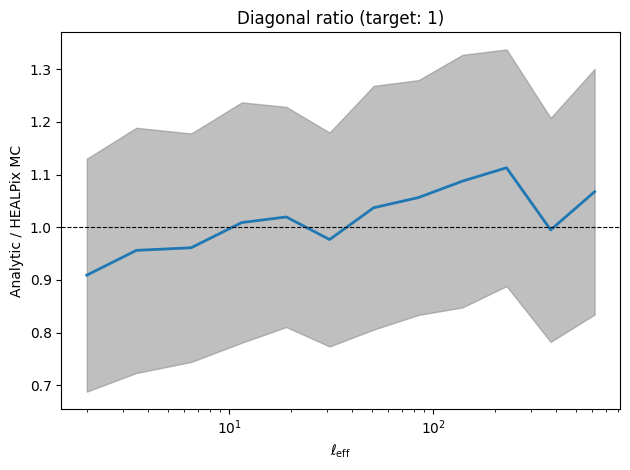

In [63]:
ell_eff = data['pcl_ell_eff']

fig, axes = plt.subplots()

Cov_sim = cov

# --- Right: ratio analytic / simulation ---
ax = axes
ax.semilogx(ell_eff, np.diag(cov_gpu_th) / np.diag(Cov_sim), lw=2)
# ax.semilogx(ell_eff, np.diag(cov_cpp) / np.diag(Cov_sim), lw=2)

ax.fill_between(ell_eff,
                (np.diag(cov_gpu_th) / np.diag(Cov_sim)) * (1 - np.sqrt(np.diag(cov_err) / np.diag(cov))),
                (np.diag(cov_gpu_th) / np.diag(Cov_sim)) * (1 + np.sqrt(np.diag(cov_err) / np.diag(cov))),
                color='gray', alpha=0.5, label='Jackknife error on data covariance')
ax.axhline(1.0, color='k', ls='--', lw=0.8)
ax.set_xlabel(r'$\ell_{\rm eff}$')
ax.set_ylabel('Analytic / HEALPix MC')
ax.set_title('Diagonal ratio (target: 1)')

plt.tight_layout()
plt.show()
fig.savefig('/home/s59efara_hpc/covariance/cpcl_gpu/var_ratio_patch.png')
np.savez("covariance_forecast.npz", cov=cov_gpu_th, ell_eff=ell_eff, cov_err=cov_err, sigma_data=sigma_data, sigma_data_err=sigma_data_err)
#np.savez("covariance_catalog.npz", cov=cov_gpu_th, ell_eff=ell_eff, cov_err=cov_err, sigma_data=sigma_data, sigma_data_err=sigma_data_err)

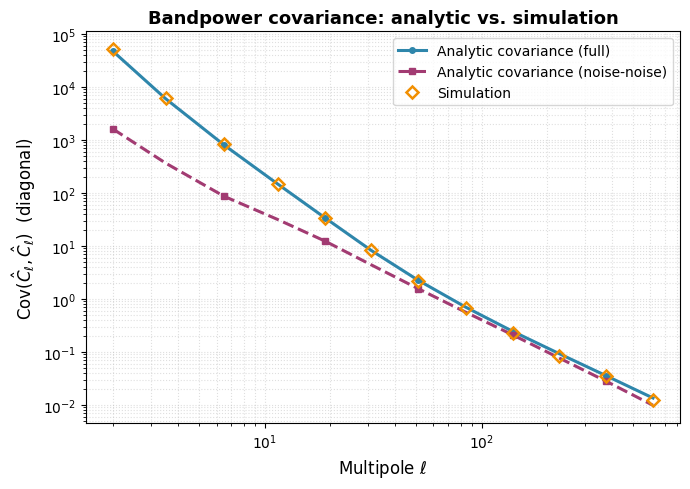

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

ax.loglog(ell_eff, np.diag(cov_gpu_th),
          color='#2E86AB', lw=2.2, marker='o', ms=4, markevery=2,
          label='Analytic covariance (full)')

ax.loglog(ell_eff, np.diag(cov_gpu_th_field_var),
          color='#A23B72', lw=2.2, ls='--', marker='s', ms=4, markevery=2,
          label='Analytic covariance (noise-noise)')

ax.loglog(ell_eff, np.diag(Cov_sim),
          color='#F18F01', lw=0, marker='D', ms=6, mfc='none', mew=1.8,
          label='Simulation')

ax.set_xlabel(r'Multipole $\ell$', fontsize=12)
ax.set_ylabel(r'$\mathrm{Cov}(\hat{C}_\ell, \hat{C}_\ell)$  (diagonal)', fontsize=12)
ax.set_title('Bandpower covariance: analytic vs. simulation', fontsize=13, fontweight='bold')

ax.legend(frameon=True, fontsize=10, loc='best')
ax.grid(True, which='both', ls=':', alpha=0.4)
fig.tight_layout()
fig.savefig('/home/s59efara_hpc/covariance/cpcl_gpu/var_patch.png')

plt.show()

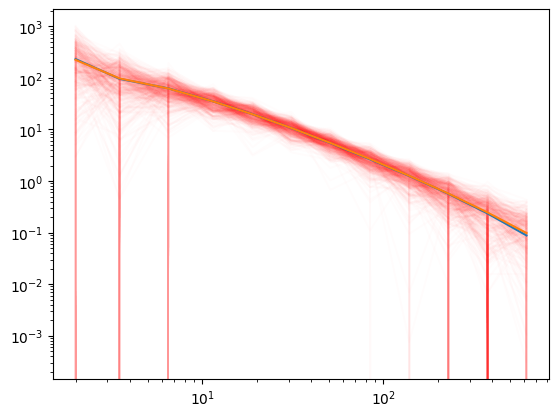

In [65]:
for i in range(500):
    plt.loglog(ell_eff, data['pcl_dm'][i], color = 'red', alpha = 0.01)
plt.plot(ell_eff, np.mean(data['pcl_dm'], axis = 0))
plt.plot(ell_eff, cl_th_decoupled[0])

/tmp/ipykernel_41557/914015336.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


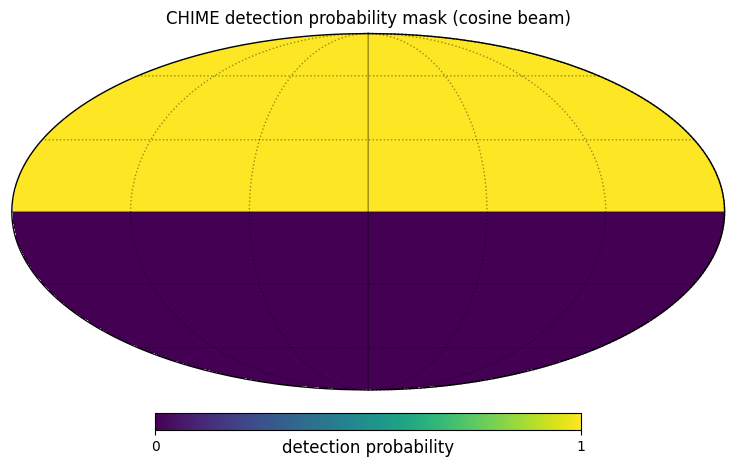

In [66]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

mask_path = "/home/s59efara_hpc/covariance/pseudo_catcell_covariance_benchmark/output/chime/chime_mask_patch_nside1024.fits"

mask = hp.read_map(mask_path)
mask = np.asarray(mask, dtype=float)

fig = plt.figure(figsize=(11, 5.5))
hp.mollview(
    mask,
    fig=fig.number,
    title="CHIME detection probability mask (cosine beam)",
    unit="detection probability",
    cmap="viridis",
    min=0.0,
    max=1.0,
    hold=True,
)
hp.graticule(dpar=30, dmer=60, alpha=0.4)
fig.tight_layout()
plt.show()